In [1]:
import pandas as pd

data = pd.read_csv('data.csv')
data['WEEK_ID'] = pd.to_datetime(data['WEEK_ID'])

data

# Eliminar filas donde ATSEG es NaN
data = data.dropna(subset=['ATSEG'])

In [ ]:
data_A = data[data['ATSEG'] == 'SEG_A'].copy()
data_B = data[data['ATSEG'] == 'SEG_B'].copy()
data_C = data[data['ATSEG'] == 'SEG_C'].copy()

# Ahora puedes explorar uno individualmente
print(f"Filas en el segmento 1: {len(data_A)}")
data_A.head()

Filas en el segmento 1: 550916


,NUEVO_ID,WEEK_ID,UC_TRX,ORAL_TRX,IL23_TRX,BRAND1_TRX,BRAND2_TRX,UC_NRX,ORAL_NRX,IL23_NRX,...,STATE_6,STS_OTHER_STS,STATE_7,STATE_8,"(1940, 1960]","(1960, 1980]","(1980, 2000]","(2000, 2020]","(2020, 2030]",ATSEG
4,9647,2024-01-12,0.1652,0.0,0.0,0.0,0.0,0.2478,0.0,0.0,...,0,0,0,1,0,1,0,0,0,SEG_A
7,9654,2024-12-06,0.1680,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,...,0,0,0,0,0,0,0,0,0,SEG_A
10,16385,2024-12-27,0.0000,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,...,0,1,0,0,0,0,1,0,0,SEG_A
11,2420,2024-11-01,0.1652,0.0,0.0,0.0,0.0,0.2478,0.0,0.0,...,0,1,0,0,1,0,0,0,0,SEG_A
16,2617,2024-03-01,0.0000,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,...,0,1,0,0,0,1,0,0,0,SEG_A


In [2]:
# 1. Agrupamos por segmento y sacamos el promedio de las variables numéricas
perfil_promedios = data.groupby('ATSEG').mean(numeric_only=True)

# 2. Transponemos (.T) para que las columnas sean filas (es más fácil de leer)
perfil_transpuesto = perfil_promedios.T

perfil_transpuesto.style.background_gradient(cmap='YlGnBu', axis=1)

ATSEG,SEG_A,SEG_B,SEG_C
NUEVO_ID,8523.225414,8162.087787,7106.723881
UC_TRX,0.171302,0.517369,0.711058
ORAL_TRX,0.023396,0.125661,0.140010
IL23_TRX,0.012664,0.059685,0.094098
BRAND1_TRX,0.000504,0.001835,0.001720
BRAND2_TRX,0.001968,0.008129,0.007383
UC_NRX,0.075294,0.228237,0.312901
ORAL_NRX,0.012158,0.058386,0.066737
IL23_NRX,0.006853,0.030581,0.047531
BRAND1_NRX,0.000265,0.000950,0.000929


In [3]:
# Creamos una columna temporal donde SEG_A es 1 y el resto es 0
data['Es_SegA'] = (data['ATSEG'] == 'SEG_A').astype(int)

# Calculamos la correlación de todas las variables numéricas contra 'Es_SegA'
correlacion_segA = data.select_dtypes(include='number').corr()['Es_SegA'].sort_values(ascending=False)

print("--- Variables con mayor correlación directa con el SEG_A ---")
# Quitamos la primera porque será 1.0 (Es_SegA vs Es_SegA)
print(correlacion_segA.iloc[1:6])

--- Variables con mayor correlación directa con el SEG_A ---
NUEVO_ID        0.077199
(1980, 2000]    0.057675
SPEC_IM         0.049708
(1940, 1960]    0.045847
STATE_1         0.035016
Name: Es_SegA, dtype: float64


In [4]:
# Creamos una columna temporal donde SEG_A es 1 y el resto es 0
data['Es_SegB'] = (data['ATSEG'] == 'SEG_B').astype(int)

correlacion_segB = data.select_dtypes(include='number').corr()['Es_SegB'].sort_values(ascending=False)

print("--- Variables con mayor correlación directa con el SEG_B ---")
print(correlacion_segB.iloc[1:6])

--- Variables con mayor correlación directa con el SEG_B ---
ORAL_TRX              0.159313
N_CLMBRAND3           0.148533
ORAL_NBRX_R4_29SUM    0.148104
UC_TRX_R4_16SUM       0.137806
UC_TRX                0.135933
Name: Es_SegB, dtype: float64


In [5]:
# Creamos una columna temporal donde SEG_A es 1 y el resto es 0
data['Es_SegC'] = (data['ATSEG'] == 'SEG_C').astype(int)

correlacion_segC = data.select_dtypes(include='number').corr()['Es_SegC'].sort_values(ascending=False)

print("--- Variables con mayor correlación directa con el SEG_C ---")
print(correlacion_segC.iloc[1:6])

--- Variables con mayor correlación directa con el SEG_C ---
UC_TRX_R4_16SUM    0.237959
UC_TRX             0.232079
N_CLMOTHERS        0.223742
UC_NRX             0.176897
IL23_TRX           0.164135
Name: Es_SegC, dtype: float64


Features: 65 columnas
Distribución de segmentos:
ATSEG
SEG_A    550916
SEG_B    288014
SEG_C    184384
Name: count, dtype: int64

── Reporte de clasificación ──
              precision    recall  f1-score   support

       SEG_A       0.75      0.73      0.74    110183
       SEG_B       0.51      0.43      0.47     57603
       SEG_C       0.37      0.48      0.41     36877

    accuracy                           0.60    204663
   macro avg       0.54      0.55      0.54    204663
weighted avg       0.61      0.60      0.60    204663



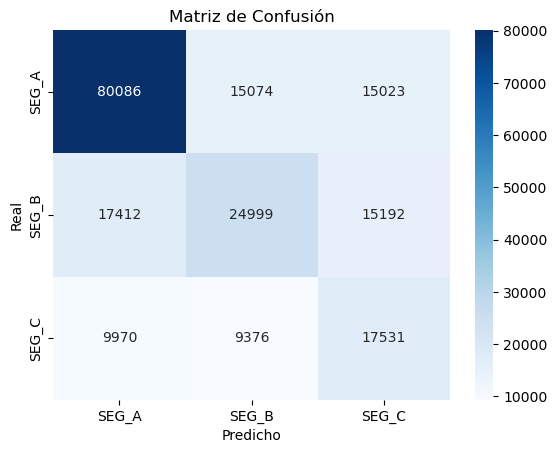

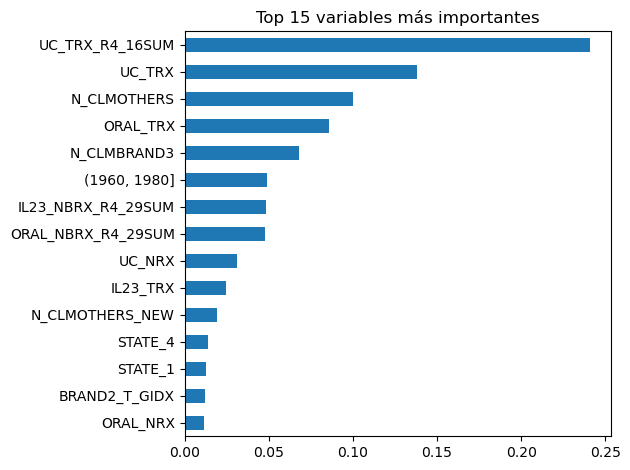

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── 1. Preparar features y target ──────────────────────────────────────────
# Excluimos columnas que no son features útiles
cols_excluir = ['ATSEG', 'WEEK_ID', 'Es_SegA', 'Es_SegB', 'Es_SegC', 'NUEVO_ID']
cols_excluir = [c for c in cols_excluir if c in data.columns]

X = data.drop(columns=cols_excluir).select_dtypes(include='number')
y = data['ATSEG']

print(f"Features: {X.shape[1]} columnas")
print(f"Distribución de segmentos:\n{y.value_counts()}")

# ── 2. Dividir en train/test ────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── 3. Entrenar Random Forest ───────────────────────────────────────────────
modelo = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    class_weight='balanced'   
)
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)

print("\n── Reporte de clasificación ──")
print(classification_report(y_test, y_pred))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred, labels=modelo.classes_)
sns.heatmap(cm, annot=True, fmt='d', 
            xticklabels=modelo.classes_, yticklabels=modelo.classes_,
            cmap='Blues')
plt.title('Matriz de Confusión')
plt.ylabel('Real'); plt.xlabel('Predicho')
plt.show()

# ── 5. Importancia de variables ─────────────────────────────────────────────
importancias = pd.Series(modelo.feature_importances_, index=X.columns)
importancias.sort_values(ascending=False).head(15).plot(kind='barh')
plt.title('Top 15 variables más importantes')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# ── 6. Predecir segmento para nuevos datos ──────────────────────────────────
# nuevos_datos = pd.DataFrame([{...tus columnas...}])
# segmento_predicho = modelo.predict(nuevos_datos)
# probabilidades   = modelo.predict_proba(nuevos_datos)